# Consolidacion de datos

**Proyecto:** Deteccion de *population drift* en modelos de prediccion de gravedad clinica de COVID-19 en Colombia.
**Entrega 2 - Fase 2:** datos, modelamiento y validacion.

Este notebook **lee el dataset crudo del INS** (descargado con `src/descargar_ins.py`, solo 9 columnas), aplica la limpieza y reduccion acordadas y exporta un CSV reducido (`dataset_reducido.csv`) que sera el insumo de todo el modelamiento posterior.

**Importante:** una vez generado `dataset_reducido.csv`, este notebook no necesita volver a ejecutarse (equivale a la etapa que se 'comenta' en el flujo final).

In [1]:
# --- Configuracion e imports ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

# Rutas
BASE = os.path.abspath("..")  # raiz de Entrega2
RAW = os.path.join(BASE, "data", "raw", "casos_covid_colombia.csv")
PROC_DIR = os.path.join(BASE, "data", "processed")
FIG_DIR = os.path.join(BASE, "figures")
OUT = os.path.join(PROC_DIR, "dataset_reducido.csv")
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Parametros de la reduccion
N_PER_OLA = 100_000     # muestreo fijo por ola (criterio 7.1 / plan)
TOP_N_CIUDADES = 15     # top ciudades + 'Otros municipios'

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

In [2]:
# --- Lectura del dataset crudo (INS) ---
df = pd.read_csv(RAW, parse_dates=["fecha_de_notificaci_n"])
print("Forma original:", df.shape)
df.head()

Forma original: (6390844, 9)


,fecha_de_notificaci_n,edad,unidad_medida,sexo,departamento_nom,ciudad_municipio_nom,fuente_tipo_contagio,ubicacion,estado
0,2020-12-22,67,1,F,VALLE,CALI,Comunitaria,Casa,Leve
1,2020-12-19,66,1,F,VALLE,CALI,Comunitaria,Casa,Leve
2,2020-12-19,68,1,F,VALLE,CALI,Comunitaria,Casa,Leve
3,2020-12-22,74,1,F,VALLE,CALI,Comunitaria,Fallecido,Fallecido
4,2020-12-22,65,1,F,VALLE,CALI,Comunitaria,Casa,Leve


In [3]:
# --- Normalizacion de texto (mayusculas / sin espacios) ---
def norm(s):
    return s.fillna("").astype(str).str.strip().str.upper()

for col in ["estado", "sexo", "ubicacion", "fuente_tipo_contagio",
            "ciudad_municipio_nom", "departamento_nom"]:
    df[col] = norm(df[col])

print("Valores unicos de estado:", sorted(df['estado'].unique()))
print("Valores unicos de ubicacion:", sorted(df['ubicacion'].unique()))
print("Valores unicos de sexo:", sorted(df['sexo'].unique()))

Valores unicos de estado: ['', 'FALLECIDO', 'GRAVE', 'LEVE', 'MODERADO']


Valores unicos de ubicacion: ['', 'CASA', 'FALLECIDO', 'HOSPITAL', 'HOSPITAL UCI']


Valores unicos de sexo: ['F', 'M']


In [4]:
# --- Edad en anios (usa unidad_medida: 1=anios, 2=meses, 3=dias) ---
edad = pd.to_numeric(df["edad"], errors="coerce")
u = pd.to_numeric(df["unidad_medida"], errors="coerce")
df["edad_anios"] = np.where(u == 2, edad / 12.0,
                             np.where(u == 3, edad / 365.0, edad))

# descartamos edades invalidas (negativas o > 120 anios)
df = df[df["edad_anios"].between(0, 120)].copy()
print("Forma tras limpiar edad:", df.shape)
df["edad_anios"].describe()

Forma tras limpiar edad: (6390844, 10)


count    6.390844e+06
mean     3.995071e+01
std      1.853216e+01
min      2.739726e-03
25%      2.700000e+01
50%      3.800000e+01
75%      5.300000e+01
max      1.140000e+02
Name: edad_anios, dtype: float64

In [5]:
# --- Construccion de la variable objetivo binaria 'grave' ---
# grave = 1 si estado en {Fallecido, Grave} O ubicacion == Hospital UCI
# grave = 0 si estado en {Leve, Moderado}
# se EXCLUYEN los estado == N/A (muertes no relacionadas con COVID-19)

GRAVES_ESTADO = {"FALLECIDO", "GRAVE"}
LEVES_ESTADO = {"LEVE", "MODERADO"}

es_grave = df["estado"].isin(GRAVES_ESTADO) | (df["ubicacion"] == "HOSPITAL UCI")
es_leve = df["estado"].isin(LEVES_ESTADO)

df["grave"] = np.where(es_grave, 1, 0)
df = df[es_grave | es_leve].copy()  # excluye N/A

print("Forma tras definir objetivo:", df.shape)
print(df["grave"].value_counts())
print("Proporcion de graves: {:.2%}".format(df['grave'].mean()))

Forma tras definir objetivo: (6349577, 11)
grave
0    6206350
1     143227
Name: count, dtype: int64
Proporcion de graves: 2.26%


In [6]:
# --- Geografia: top 15 ciudades + 'Otros municipios' ---
# Evitamos fuga de datos calculando el top SOLO con el anio 2020
mask_2020 = df["fecha_de_notificaci_n"].dt.year == 2020
top_ciudades = df.loc[mask_2020, "ciudad_municipio_nom"].value_counts().head(TOP_N_CIUDADES).index.tolist()
df["ciudad_top"] = np.where(
    df["ciudad_municipio_nom"].isin(top_ciudades),
    df["ciudad_municipio_nom"],
    "OTROS MUNICIPIOS",
)
print("Top ciudades conservadas (calculado sobre 2020):")
print(top_ciudades)
print("\nDistribucion ciudad_top:")
print(df["ciudad_top"].value_counts())

Top ciudades conservadas (calculado sobre 2020):
['BOGOTA', 'MEDELLIN', 'CALI', 'BARRANQUILLA', 'CARTAGENA', 'IBAGUE', 'BUCARAMANGA', 'CUCUTA', 'VILLAVICENCIO', 'PEREIRA', 'NEIVA', 'MANIZALES', 'VALLEDUPAR', 'BELLO', 'PASTO']

Distribucion ciudad_top:


ciudad_top
OTROS MUNICIPIOS    2265538
BOGOTA              1878355
MEDELLIN             547980
CALI                 403394
BARRANQUILLA         276065
CARTAGENA            162780
BUCARAMANGA          142059
IBAGUE                90986
MANIZALES             83866
CUCUTA                76721
VALLEDUPAR            76017
VILLAVICENCIO         75299
PEREIRA               72934
BELLO                 72381
NEIVA                 63995
PASTO                 61207
Name: count, dtype: int64


In [7]:
# --- Etiqueta de ola (particion temporal) ---
anio = df["fecha_de_notificaci_n"].dt.year
df["anio"] = anio

# Alcance del proyecto: 2020 (ola original), 2021 (Delta), 2022 (Omicron).
# Los registros 2023-2024 (fase endemica, posteriores) quedan fuera del alcance.
df = df[anio.isin([2020, 2021, 2022])].copy()
anio = df["anio"]

df["ola"] = np.select(
    [anio == 2020, anio == 2021, anio == 2022],
    ["2020 (original)", "2021 (Delta)", "2022 (Omicron)"],
    default="Otro",
)
print(df["ola"].value_counts())
print("\nProporcion de graves por ola (datos crudos):")
print(df.groupby("ola")["grave"].agg(["size", "mean"]))

ola
2021 (Delta)       3506739
2020 (original)    1746914
2022 (Omicron)     1057752
Name: count, dtype: int64

Proporcion de graves por ola (datos crudos):


                    size      mean
ola                               
2020 (original)  1746914  0.028209
2021 (Delta)     3506739  0.023271
2022 (Omicron)   1057752  0.010977


In [8]:
# --- Muestreo estratificado por ola (N fijo por ola) ---
def sample_stratified(g, n, seed):
    if len(g) <= n:
        return g
    frac = n / len(g)
    return g.groupby("grave", group_keys=False, sort=False).sample(frac=frac, random_state=seed)

muestras = []
for ola, g in df.groupby("ola", sort=False):
    s = sample_stratified(g, N_PER_OLA, SEED)
    print(f"{ola}: {len(g):>8,} -> {len(s):>8,} (graves {s['grave'].mean():.2%})")
    muestras.append(s)

df_red = pd.concat(muestras, ignore_index=True)
print("\nForma final del dataset reducido:", df_red.shape)

2020 (original): 1,746,914 ->  100,000 (graves 2.82%)


2021 (Delta): 3,506,739 ->  100,000 (graves 2.33%)


2022 (Omicron): 1,057,752 ->  100,000 (graves 1.10%)

Forma final del dataset reducido: (300000, 14)


In [9]:
# --- Exportar dataset reducido ---
df_red.to_csv(OUT, index=False)
print("Exportado a:", OUT)
df_red.head()

Exportado a: \\wsl.localhost\Ubuntu-24.04\home\fabri\code\Semestre 5\MachineLearning2\Proyecto\Entrega2\data\processed\dataset_reducido.csv


,fecha_de_notificaci_n,edad,unidad_medida,sexo,departamento_nom,ciudad_municipio_nom,fuente_tipo_contagio,ubicacion,estado,edad_anios,grave,ciudad_top,anio,ola
0,2020-09-11,17,1,F,BOGOTA,BOGOTA,COMUNITARIA,CASA,LEVE,17.0,0,BOGOTA,2020,2020 (original)
1,2020-08-22,14,1,F,CUNDINAMARCA,SOACHA,COMUNITARIA,CASA,LEVE,14.0,0,OTROS MUNICIPIOS,2020,2020 (original)
2,2020-12-21,37,1,F,ANTIOQUIA,MEDELLIN,COMUNITARIA,CASA,LEVE,37.0,0,MEDELLIN,2020,2020 (original)
3,2020-10-08,38,1,M,SANTANDER,GIRON,RELACIONADO,CASA,LEVE,38.0,0,OTROS MUNICIPIOS,2020,2020 (original)
4,2020-11-15,56,1,M,BOGOTA,BOGOTA,RELACIONADO,CASA,LEVE,56.0,0,BOGOTA,2020,2020 (original)


In [10]:
# --- Verificacion de estructura (criterio 7.1) ---
print("Nulos por columna (reducido):")
print(df_red.isna().sum())
print("\nProporcion de graves por ola (reducido):")
print(df_red.groupby("ola")["grave"].agg(["size", "mean"]))

Nulos por columna (reducido):


fecha_de_notificaci_n    0
edad                     0
unidad_medida            0
sexo                     0
departamento_nom         0
ciudad_municipio_nom     0
fuente_tipo_contagio     0
ubicacion                0
estado                   0
edad_anios               0
grave                    0
ciudad_top               0
anio                     0
ola                      0
dtype: int64

Proporcion de graves por ola (reducido):


                   size     mean
ola                             
2020 (original)  100000  0.02821
2021 (Delta)     100000  0.02327
2022 (Omicron)   100000  0.01098


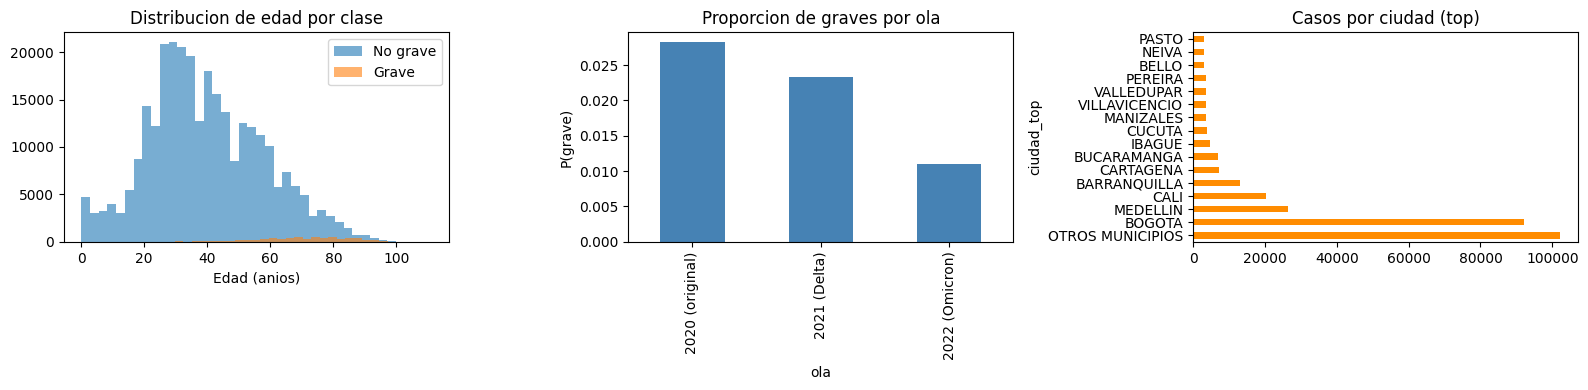

In [11]:
# --- Figuras de verificacion ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_red.loc[df_red['grave'] == 0, 'edad_anios'], bins=40, alpha=0.6, label='No grave')
axes[0].hist(df_red.loc[df_red['grave'] == 1, 'edad_anios'], bins=40, alpha=0.6, label='Grave')
axes[0].set_title('Distribucion de edad por clase')
axes[0].set_xlabel('Edad (anios)')
axes[0].legend()

df_red.groupby('ola')['grave'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Proporcion de graves por ola')
axes[1].set_ylabel('P(grave)')

df_red['ciudad_top'].value_counts().head(16).plot(kind='barh', ax=axes[2], color='darkorange')
axes[2].set_title('Casos por ciudad (top)')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'verificacion_estructura.png'), dpi=150, bbox_inches='tight')
plt.show()

## Fin de la reduccion

`dataset_reducido.csv` esta listo. El resto del flujo (pipeline, simulacion, modelos, OCSVM, validacion) se realiza en `02_modelado.ipynb`, que lee ese archivo directamente.